# Descriptive Analysis: WritingPrompts Story Generations

**Dataset:** WritingPrompts (Fan et al., 2018), test split — 100 sampled prompts, `seed=42`
**Models:** 4 open-weight instruction-tuned LLMs, run locally via vLLM:

- Gemma: google/gemma-2-9b-it
- Llama: meta-llama/Llama-3.1-8B-Instruct
- Mistral: mistralai/Mistral-7B-Instruct-v0.3
- Qwen: Qwen/Qwen2.5-7B-Instruct

**Decoding:** `temperature=1.0`, `top_p=0.9`, `repetition_penalty=1.0` (disabled), `n=5` samples per prompt (500 stories per model)
**Reference:** 1 human-written story per prompt (`prompts_sample.jsonl`)

In [56]:
# Load libraries
import json
import collections
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [58]:
# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Locate the repo root regardless of the kernel's working directory
def find_repo_root(start=pathlib.Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'generations' / 'storytelling').is_dir():
            return p
    raise FileNotFoundError("Could not locate 'generations/storytelling' above the current directory")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'generations' / 'storytelling'
FIG_DIR = REPO_ROOT / 'figures' / 'storytelling'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {
    'gemma':   'google/gemma-2-9b-it',
    'llama':   'meta-llama/Llama-3.1-8B-Instruct',
    'mistral': 'mistralai/Mistral-7B-Instruct-v0.3',
    'qwen':    'Qwen/Qwen2.5-7B-Instruct',
}

MODEL_LABELS = {
    'gemma': 'Gemma-2-9B', 'llama': 'Llama-3.1-8B',
    'mistral': 'Mistral-7B-v0.3', 'qwen': 'Qwen2.5-7B', 'human': 'Human',
}

MODEL_COLORS = {
    'Human':            '#cb1f73',
    'Gemma-2-9B':       '#fcc72d',
    'Llama-3.1-8B':     '#ea6d3d',
    'Mistral-7B-v0.3':  '#e03a3c',
    'Qwen2.5-7B':       '#383a6b',
}

MODEL_ORDER = ['Human', 'Gemma-2-9B', 'Llama-3.1-8B', 'Mistral-7B-v0.3', 'Qwen2.5-7B']
GEN_ORDER = [m for m in MODEL_ORDER if m != 'Human']

## Load & Prepare Data

In [59]:
# Generation configs (identical decoding params across models, saved per run)
configs = {key: json.load(open(DATA_DIR / f'config_{key}.json')) for key in MODELS}
config_overview = pd.DataFrame(configs).T[
    ['model_id', 'n_prompts', 'n_samples', 'temperature', 'top_p', 'repetition_penalty', 'max_new_tokens']
]
display(config_overview)

,model_id,n_prompts,n_samples,temperature,top_p,repetition_penalty,max_new_tokens
gemma,google/gemma-2-9b-it,100,5,1.0,0.9,1.0,1280
llama,meta-llama/Llama-3.1-8B-Instruct,100,5,1.0,0.9,1.0,1280
mistral,mistralai/Mistral-7B-Instruct-v0.3,100,5,1.0,0.9,1.0,1280
qwen,Qwen/Qwen2.5-7B-Instruct,100,5,1.0,0.9,1.0,1280


In [60]:
# Load generated stories (4 models x 100 prompts x 5 samples)
records = []
for key in MODELS:
    with open(DATA_DIR / f'writingprompts_{key}_n5.jsonl') as f:
        for line in f:
            r = json.loads(line)
            r['model_key'] = key
            records.append(r)

df_gen = pd.DataFrame(records)
df_gen['model'] = df_gen['model_key'].map(MODEL_LABELS)
df_gen['word_count'] = df_gen['story'].str.split().str.len()
df_gen['char_count'] = df_gen['story'].str.len()

print(f'Loaded {len(df_gen)} generated stories')
df_gen.head(3)

Loaded 2000 generated stories


,prompt_id,prompt,model,sample_idx,story,finish_reason,n_tokens,cjk_chars,language_ok,model_key,word_count,char_count
0,wp_0000,The first line of your story must include'and ...,Gemma-2-9B,0,"And I caught him with, of all things, a fishin...",stop,648,0,True,gemma,472,2718
1,wp_0000,The first line of your story must include'and ...,Gemma-2-9B,1,"And I caught him with, of all things, a fishin...",stop,630,0,True,gemma,439,2589
2,wp_0000,The first line of your story must include'and ...,Gemma-2-9B,2,"And I caught him with, of all things, a fishin...",stop,683,0,True,gemma,498,2762


In [61]:
# Load human reference stories (1 per prompt)
human_records = [json.loads(l) for l in open(DATA_DIR / 'prompts_sample.jsonl')]
df_human = pd.DataFrame(human_records)
df_human['model_key'] = 'human'
df_human['model'] = 'Human'
df_human['story'] = df_human['human_story']
df_human['word_count'] = df_human['story'].str.split().str.len()
df_human['char_count'] = df_human['story'].str.len()
df_human['prompt_word_count'] = df_human['prompt'].str.split().str.len()

print(f'Loaded {len(df_human)} human reference stories')
df_human.head(3)

Loaded 100 human reference stories


,prompt,human_story,prompt_id,model_key,model,story,word_count,char_count,prompt_word_count
0,The first line of your story must include'and ...,"`` There he was, standing over the toilet, and...",wp_0000,human,Human,"`` There he was, standing over the toilet, and...",413,2143,18
1,Three friends. Four AM. No dialogue,Josh sat motionless. The hall ’ s carpeted rug...,wp_0001,human,Human,Josh sat motionless. The hall ’ s carpeted rug...,622,3322,6
2,"`` I hope I'm not bothering you, good sir. I'm...","`` I hope I'm not bothering you, good sir, I'm...",wp_0002,human,Human,"`` I hope I'm not bothering you, good sir, I'm...",517,2858,17


## Sanity Checks

In [63]:
# Coverage: 
# - every model should have exactly 5 samples for each of the 100 prompts
# - all 5 sources (4 models + human) should refer to the same 100 prompts

samples_per_prompt = df_gen.groupby(['model_key', 'prompt_id']).size()
print(f'Generated stories: {len(df_gen)}  ({df_gen.model_key.nunique()} models x '
      f'{df_gen.prompt_id.nunique()} prompts x {samples_per_prompt.mean():.0f} samples)')
print(f'Samples per prompt (min / max): {samples_per_prompt.min()} / {samples_per_prompt.max()}')
print(f'Human reference stories: {len(df_human)}')

prompt_id_sets = {key: frozenset(df_gen.loc[df_gen.model_key == key, 'prompt_id']) for key in MODELS}
prompt_id_sets['human'] = frozenset(df_human['prompt_id'])
print('All 5 sources share the same 100 prompt_ids:', len(set(prompt_id_sets.values())) == 1)

# Same prompt text across models (join key sanity check)
prompt_text = df_gen.drop_duplicates('prompt_id').set_index('prompt_id')['prompt']
human_prompt_text = df_human.set_index('prompt_id')['prompt']
print('Prompt text identical across generation + human files:',
      prompt_text.reindex(human_prompt_text.index).equals(human_prompt_text))

Generated stories: 2000  (4 models x 100 prompts x 5 samples)
Samples per prompt (min / max): 5 / 5
Human reference stories: 100
All 5 sources share the same 100 prompt_ids: True
Prompt text identical across generation + human files: True


## Generation Quality Checks

Fields logged during generation: `finish_reason`, `n_tokens`, `cjk_chars`, `language_ok` 

In [65]:
# Truncation: finish_reason == 'length'
finish_tab = pd.crosstab(df_gen['model'], df_gen['finish_reason']).reindex(GEN_ORDER)
finish_tab['truncated_%'] = (finish_tab.get('length', 0) / finish_tab.sum(axis=1) * 100).round(1)
display(finish_tab)

finish_reason,length,stop,truncated_%
model,,,
Gemma-2-9B,0,500,0.0
Llama-3.1-8B,0,500,0.0
Mistral-7B-v0.3,7,493,1.4
Qwen2.5-7B,1,499,0.2


In [66]:
# Language drift: non-Latin (CJK) script detected in an otherwise English story
lang_tab = df_gen.groupby('model').agg(
    non_english=('language_ok', lambda s: int((~s).sum())),
    max_cjk_chars=('cjk_chars', 'max'),
).reindex(GEN_ORDER)
display(lang_tab)

flagged = df_gen[~df_gen['language_ok']]
if len(flagged):
    print('\nFlagged stories:')
    for _, r in flagged.iterrows():
        share = r['cjk_chars'] / len(r['story'])
        print(f"  {r['model']} / {r['prompt_id']} / sample {r['sample_idx']}: {share:.1%} CJK characters")

,non_english,max_cjk_chars
model,,
Gemma-2-9B,0,0
Llama-3.1-8B,0,0
Mistral-7B-v0.3,0,0
Qwen2.5-7B,1,425



Flagged stories:
  Qwen2.5-7B / wp_0044 / sample 4: 14.1% CJK characters


In [67]:
# Exact duplicates: identical story text sampled twice
dup_counts = df_gen.groupby('model')['story'].apply(lambda s: len(s) - s.nunique()).reindex(GEN_ORDER)
print('Exact duplicate stories per model:')
print(dup_counts)

Exact duplicate stories per model:
model
Gemma-2-9B         0
Llama-3.1-8B       0
Mistral-7B-v0.3    0
Qwen2.5-7B         0
Name: story, dtype: int64


In [68]:
# Repeated openings: how concentrated are the first few words across all 500 stories per model?
def top_opening_share(stories, n_words=4):
    openings = collections.Counter(' '.join(s.split()[:n_words]) for s in stories)
    opening, count = openings.most_common(1)[0]
    return count / len(stories), opening

quality_rows = []
for key in MODELS:
    sub = df_gen[df_gen.model_key == key]
    n = len(sub)
    share, opening = top_opening_share(sub['story'])
    quality_rows.append({
        'model': MODEL_LABELS[key],
        'truncated_%': (sub['finish_reason'] == 'length').mean() * 100,
        'non_english_%': (~sub['language_ok']).mean() * 100,
        'exact_dup_%': (n - sub['story'].nunique()) / n * 100,
        'top_opening_share_%': share * 100,
        'top_opening': opening,
    })

quality_df = pd.DataFrame(quality_rows).set_index('model').reindex(GEN_ORDER)
display(quality_df.round(2))

,truncated_%,non_english_%,exact_dup_%,top_opening_share_%,top_opening
model,,,,,
Gemma-2-9B,0.0,0.0,0.0,3.0,Rain lashed against the
Llama-3.1-8B,0.0,0.0,0.0,2.2,I stared at the
Mistral-7B-v0.3,1.4,0.0,0.0,33.4,In the heart of
Qwen2.5-7B,0.2,0.2,0.0,4.4,In the heart of


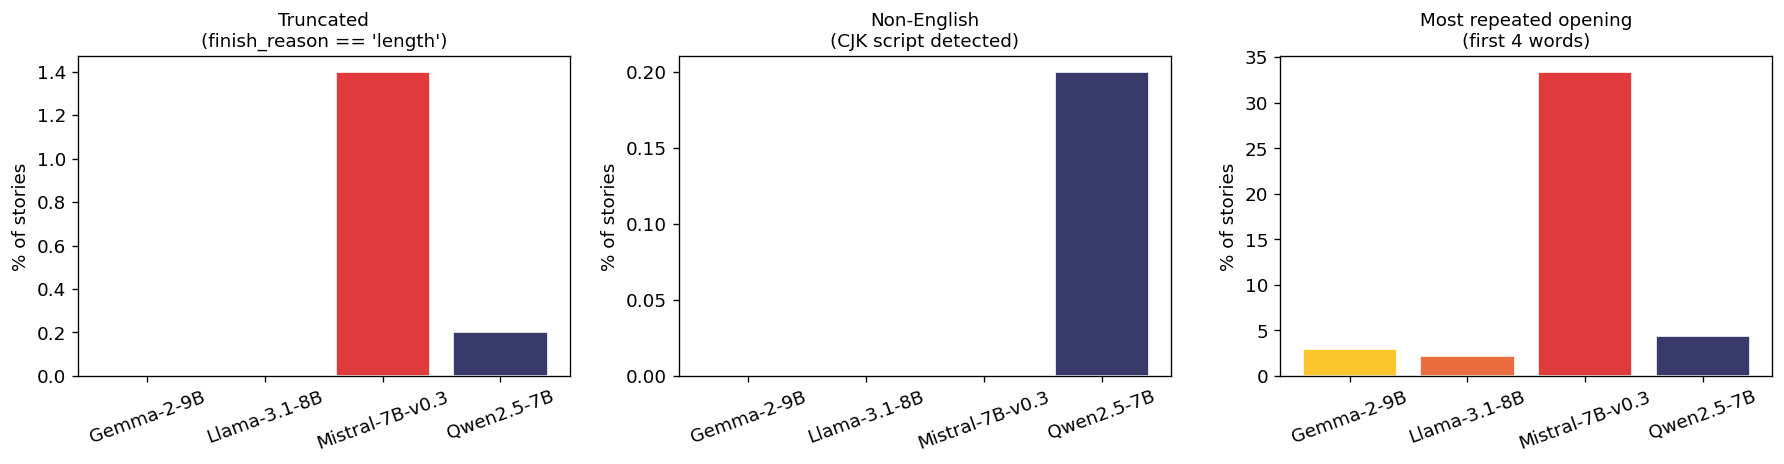

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['truncated_%', 'non_english_%', 'top_opening_share_%']
titles = ["Truncated\n(finish_reason == 'length')", 'Non-English\n(CJK script detected)',
          'Most repeated opening\n(first 4 words)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    colors = [MODEL_COLORS[m] for m in quality_df.index]
    ax.bar(quality_df.index, quality_df[metric], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('% of stories')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_generation_quality.png', dpi=300, bbox_inches='tight')
plt.show()

## Filtering Degenerate Generations

exclude the 8 truncated stories (`finish_reason == 'length'`) and the 1 story with language drift (`language_ok == False`, 14% CJK characters) identified above

In [70]:
exclude_mask = (df_gen['finish_reason'] == 'length') | (~df_gen['language_ok'])

print(f'Excluding {exclude_mask.sum()} of {len(df_gen)} generated stories ({exclude_mask.mean():.1%}):')
print(df_gen.loc[exclude_mask, ['model', 'prompt_id', 'sample_idx', 'finish_reason', 'language_ok']]
      .to_string(index=False))

df_excluded = df_gen[exclude_mask].copy()
df_gen = df_gen[~exclude_mask].reset_index(drop=True)

print('\nRemaining stories per model:')
print(df_gen['model'].value_counts().reindex(GEN_ORDER))

Excluding 9 of 2000 generated stories (0.4%):
          model prompt_id  sample_idx finish_reason  language_ok
Mistral-7B-v0.3   wp_0004           4        length         True
Mistral-7B-v0.3   wp_0005           1        length         True
Mistral-7B-v0.3   wp_0015           2        length         True
Mistral-7B-v0.3   wp_0021           3        length         True
Mistral-7B-v0.3   wp_0030           0        length         True
Mistral-7B-v0.3   wp_0045           4        length         True
Mistral-7B-v0.3   wp_0094           4        length         True
     Qwen2.5-7B   wp_0029           0        length         True
     Qwen2.5-7B   wp_0044           4          stop        False

Remaining stories per model:
model
Gemma-2-9B         500
Llama-3.1-8B       500
Mistral-7B-v0.3    493
Qwen2.5-7B         498
Name: count, dtype: int64


## Length Distributions

In [71]:
df_all = pd.concat([
    df_gen[['prompt_id', 'model', 'word_count', 'char_count']],
    df_human[['prompt_id', 'model', 'word_count', 'char_count']],
], ignore_index=True)

length_summary = df_all.groupby('model')['word_count'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).reindex(MODEL_ORDER).round(1)
display(length_summary)

,count,mean,median,std,min,max
model,,,,,,
Human,100,524.2,449.5,341.7,108,1778
Gemma-2-9B,500,479.4,476.0,65.2,251,738
Llama-3.1-8B,500,500.4,499.0,58.7,335,1111
Mistral-7B-v0.3,493,558.6,549.0,102.5,279,959
Qwen2.5-7B,498,554.2,545.0,111.6,131,918


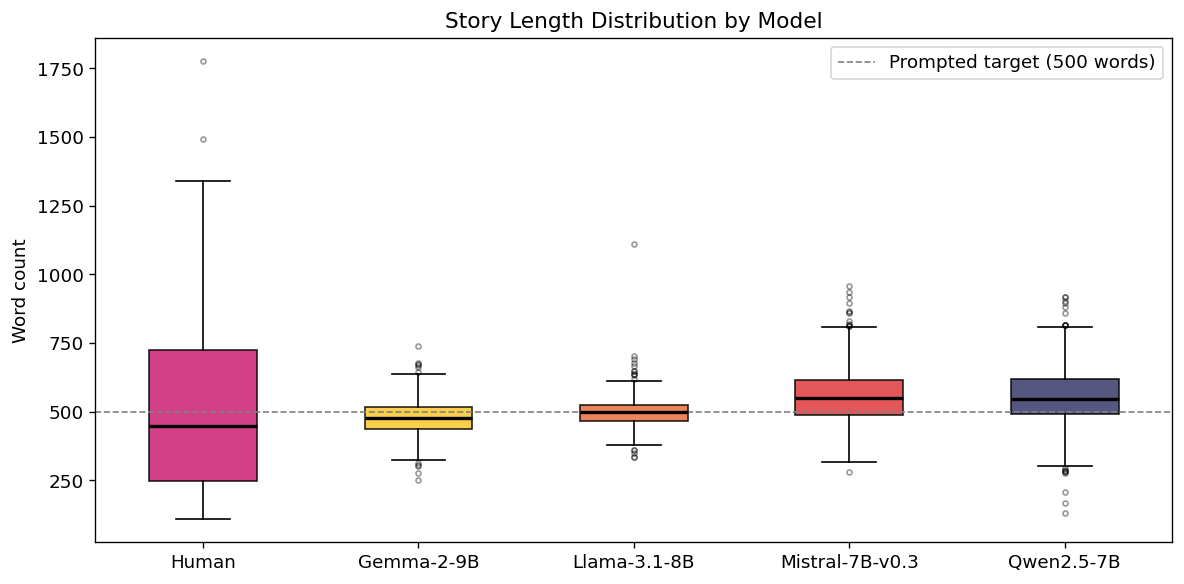

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df_all.loc[df_all.model == m, 'word_count'].values for m in MODEL_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=MODEL_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.axhline(500, color='gray', linestyle='--', linewidth=1, label='Prompted target (500 words)')
ax.set_ylabel('Word count')
ax.set_title('Story Length Distribution by Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_length_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

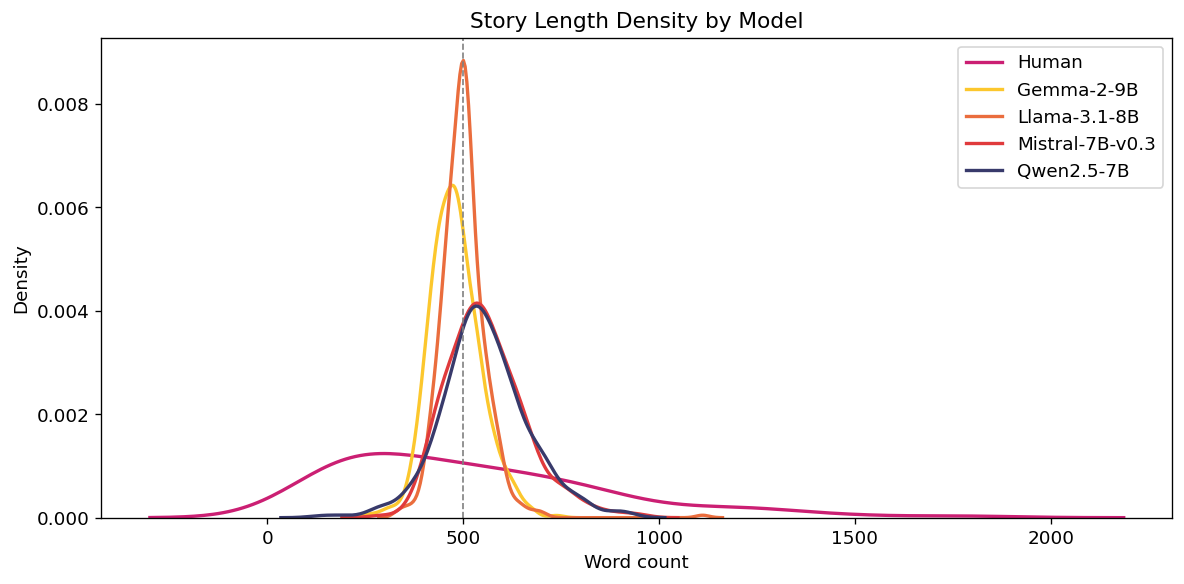

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))
for m in MODEL_ORDER:
    sns.kdeplot(df_all.loc[df_all.model == m, 'word_count'], label=m,
                color=MODEL_COLORS[m], linewidth=2, ax=ax)
ax.axvline(500, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Word count')
ax.set_title('Story Length Density by Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_length_kde.png', dpi=300, bbox_inches='tight')
plt.show()

## Within-Prompt Length Variability

For each prompt, models produce 5 independent samples. The spread of word counts *within* the same prompt indicates
how consistently a model controls output length, as opposed to variability *across* different prompts.

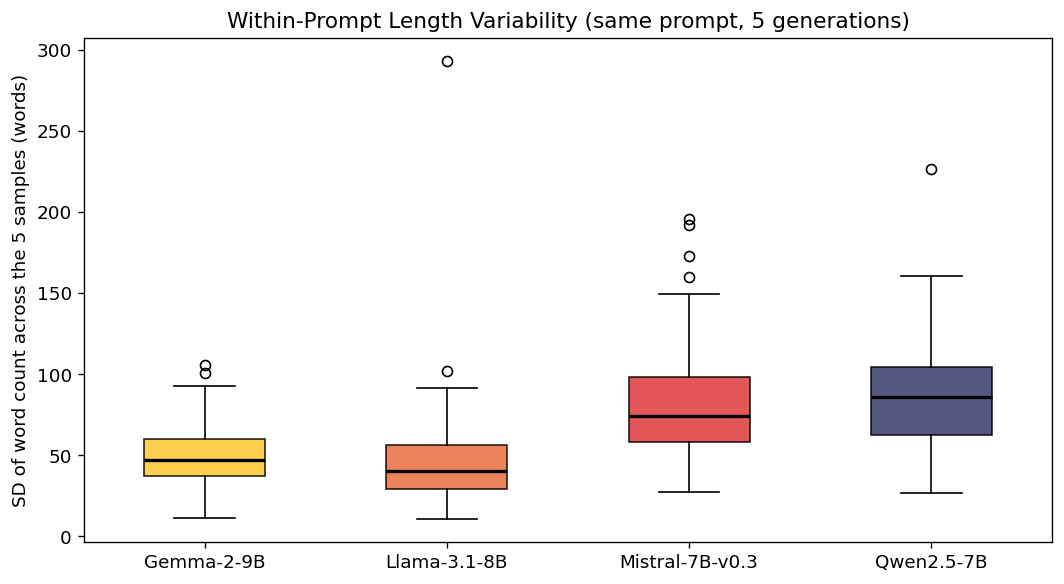

Mean within-prompt SD by model:
model
Gemma-2-9B         49.4
Llama-3.1-8B       45.3
Mistral-7B-v0.3    81.4
Qwen2.5-7B         85.5
Name: within_prompt_sd, dtype: float64


In [74]:
within_std = (df_gen.groupby(['model', 'prompt_id'])['word_count']
              .std().reset_index().rename(columns={'word_count': 'within_prompt_sd'}))

fig, ax = plt.subplots(figsize=(9, 5))
data = [within_std.loc[within_std.model == m, 'within_prompt_sd'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('SD of word count across the 5 samples (words)')
ax.set_title('Within-Prompt Length Variability (same prompt, 5 generations)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_within_prompt_variability.png', dpi=300, bbox_inches='tight')
plt.show()

print('Mean within-prompt SD by model:')
print(within_std.groupby('model')['within_prompt_sd'].mean().reindex(GEN_ORDER).round(1))

## Tokenizer Efficiency (tokens vs. words)

,mean,std
model,,
Gemma-2-9B,1.34,0.06
Llama-3.1-8B,1.27,0.05
Mistral-7B-v0.3,1.40,0.08
Qwen2.5-7B,1.26,0.08


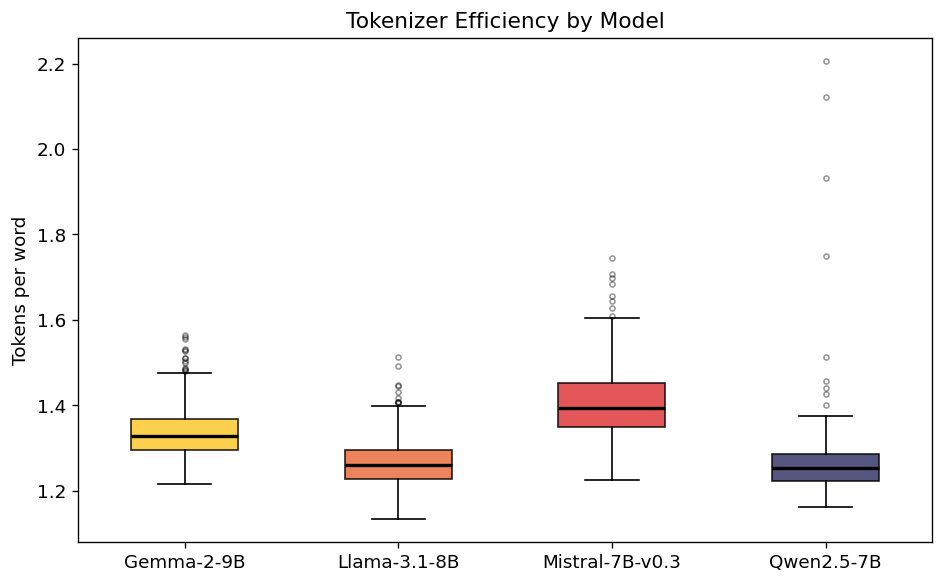

In [75]:
df_gen['tokens_per_word'] = df_gen['n_tokens'] / df_gen['word_count']
tok_summary = df_gen.groupby('model')['tokens_per_word'].agg(['mean', 'std']).reindex(GEN_ORDER).round(2)
display(tok_summary)

fig, ax = plt.subplots(figsize=(8, 5))
data = [df_gen.loc[df_gen.model == m, 'tokens_per_word'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('Tokens per word')
ax.set_title('Tokenizer Efficiency by Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_tokens_per_word.png', dpi=300, bbox_inches='tight')
plt.show()

## Prompt Length vs. Story Length

Pearson r(prompt length, story length) by model:
model
Gemma-2-9B         0.03
Llama-3.1-8B       0.02
Mistral-7B-v0.3    0.08
Qwen2.5-7B         0.12
dtype: float64


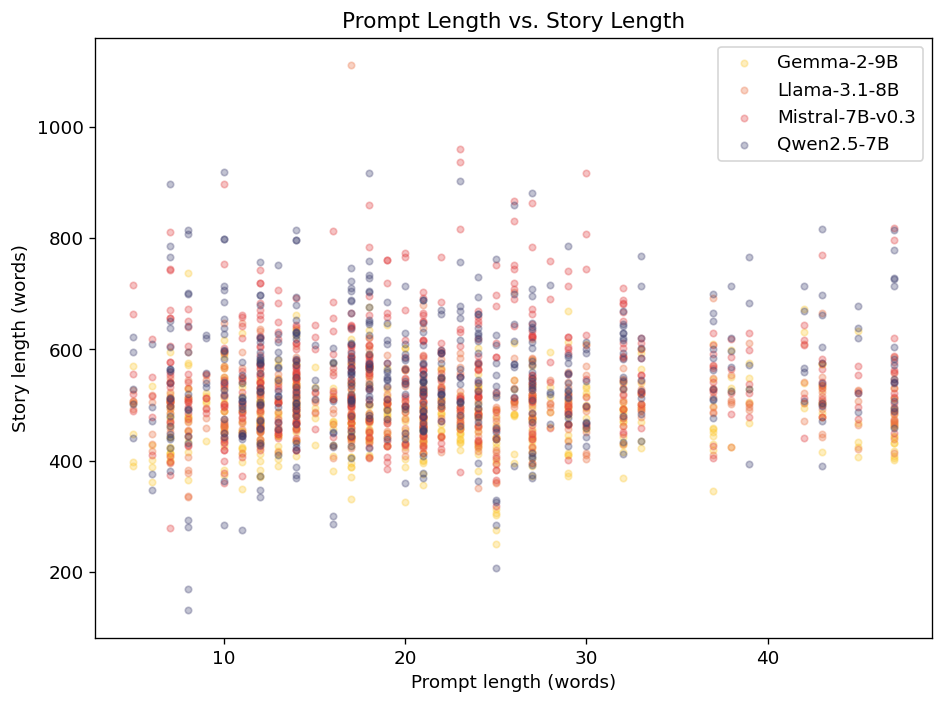

In [76]:
merged = df_gen.merge(df_human[['prompt_id', 'prompt_word_count']], on='prompt_id')
corr_by_model = merged.groupby('model').apply(
    lambda g: g['prompt_word_count'].corr(g['word_count'])
).reindex(GEN_ORDER)
print('Pearson r(prompt length, story length) by model:')
print(corr_by_model.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
for m in GEN_ORDER:
    sub = merged[merged.model == m]
    ax.scatter(sub['prompt_word_count'], sub['word_count'], alpha=0.3, s=15,
               color=MODEL_COLORS[m], label=m)
ax.set_xlabel('Prompt length (words)')
ax.set_ylabel('Story length (words)')
ax.set_title('Prompt Length vs. Story Length')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_prompt_vs_story_length.png', dpi=300, bbox_inches='tight')
plt.show()

## Qualitative Sample: One Prompt Across All Models

In [77]:
example_ids = ['wp_0000', 'wp_0099', 'wp_0007']

for example_id in example_ids:
    print(f'{"="*80}\nPROMPT_ID: {example_id}')
    print('PROMPT:', df_human.loc[df_human.prompt_id == example_id, 'prompt'].iloc[0])
    print()

    for key, label in MODEL_LABELS.items():
        if key == 'human':
            story = df_human.loc[df_human.prompt_id == example_id, 'story'].iloc[0]
        else:
            story = df_gen.loc[(df_gen.model_key == key) & (df_gen.prompt_id == example_id)
                                & (df_gen.sample_idx == 0), 'story'].iloc[0]
        print(f'--- {label} ({len(story.split())} words) ---')
        print(story[:400] + ('...' if len(story) > 400 else ''))
        print()
    print()

PROMPT_ID: wp_0000
PROMPT: The first line of your story must include'and I caught him with, of all things, a fishing pole'.

--- Gemma-2-9B (472 words) ---
And I caught him with, of all things, a fishing pole.  Not the sleek, modern kind you see in magazines, but a clunky, well-worn wooden one, its paint chipped and faded.  He'd snagged it from a pile of old sporting goods in the back of our shared garage, presumably under the cover of a rare moment when I wasn't around.  I stared at him, the ridiculous sight of him with that thing a stark contrast t...

--- Llama-3.1-8B (455 words) ---
And I caught him with, of all things, a fishing pole, its rod bent under the weight of a gaudy, blue and green striped fish that flailed wildly as it fought for freedom. I stared at him in confusion, trying to reconcile the image of my uptight, by-the-book boss with the unlikely picture of a fisherman. He was a man who wore three-piece suits and clutching briefcases, not a vest and waders.

I appr...

-

## Summary

In [78]:
summary = length_summary.copy()
summary['truncated_%'] = quality_df['truncated_%'].reindex(MODEL_ORDER)
summary['non_english_%'] = quality_df['non_english_%'].reindex(MODEL_ORDER)
summary['exact_dup_%'] = quality_df['exact_dup_%'].reindex(MODEL_ORDER)

summary.to_csv(FIG_DIR / 'storytelling_summary_stats.csv')
display(summary.style.background_gradient(subset=['mean'], cmap='Blues')
        .set_caption('Descriptive Summary: WritingPrompts Story Generations'))

,count,mean,median,std,min,max,truncated_%,non_english_%,exact_dup_%
model,,,,,,,,,
Human,100,524.200000,449.500000,341.700000,108,1778,nan,nan,nan
Gemma-2-9B,500,479.400000,476.000000,65.200000,251,738,0.000000,0.000000,0.000000
Llama-3.1-8B,500,500.400000,499.000000,58.700000,335,1111,0.000000,0.000000,0.000000
Mistral-7B-v0.3,493,558.600000,549.000000,102.500000,279,959,1.400000,0.000000,0.000000
Qwen2.5-7B,498,554.200000,545.000000,111.600000,131,918,0.200000,0.200000,0.000000
